# FRESCO Data Download

This notebook search and download FRESCO data from the NASA MAST database. Note that since we want to do the mosaic for each NIRCam grism mode separately, and forward model the emission line with proper PSF estimate, we need the `rate` frames and do our own mosaic. 

An example download script for the GOODS-S field can be find in `/xdisk/timeifler/jiachuanxu/jwst/fresco/download_fresco_grism_F444W_001.sh`. Basic command is 
> echo "<<< Downloading File [2/128]: jw01895001001_02101_00001_nrcblong_rate.fits"

> curl --globoff --location-trusted -f --progress-bar --output './grism_F444W/jw01895001001_02101_00001_nrcblong_rate.fits' 'https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/jw01895001001_02101_00001_nrcblong_rate.fits'

The JWST MAST filename convention is 

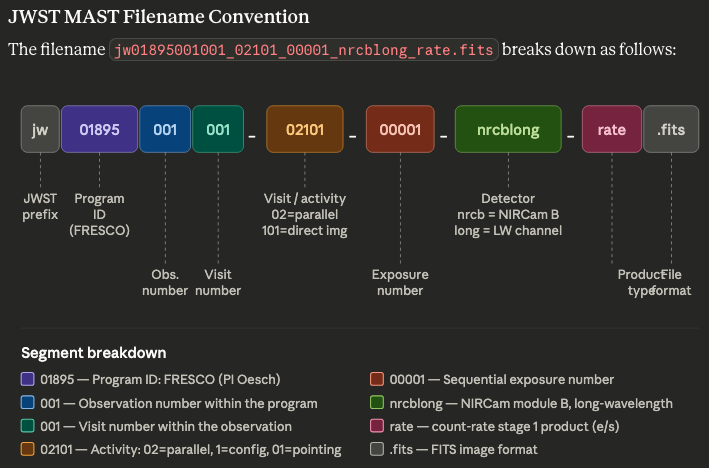

- `jw` — Fixed prefix identifying all JWST files on MAST.
- `01895` — The 5-digit proposal/program ID. 01895 is FRESCO (First Reionization Epoch Spectroscopically Complete Observations), PI Pascal Oesch.
- `001` (first) — Observation number within the program. Programs are divided into multiple observations targeting different fields or configurations.
- `001` (second) — Visit number within that observation. A single observation may have multiple visits (e.g. separate epochs or dithers).
- `02101` — This is the 5-digit visit/activity code, and the most cryptic part:
    - `02` — the parallel sequence identifier (`02` means this is a coordinated parallel, `01` would be the primary)
    - `1` — the activity type/configuration slot
    - `01` — the pointing/dither position within that activity
    So `02101` effectively encodes which pointing in which activity sequence this exposure belongs to.
- `00001` — Sequential 5-digit exposure number. Resets per visit.
- `nrcblong` — The detector. For NIRCam this breaks down as:
    - `nrc` = NIRCam
    - `a` or `b` = module (A or B; the two back-to-back NIRCam modules)
    - `long` = long-wavelength channel (2.4–5 µm); `short` would be the SW channel. Alternatives you'll see: `nrca1`–`nrca4`, `nrcb1`–`nrcb4` (individual SW detectors), `nrcalong`, `nrcblong`.
- `rate` — The pipeline processing stage/product type:
    - `uncalRaw` uncalibrated ramps
    - `rate` Stage 1 output: count-rate image (e⁻/s), ramp-fitted 
    - `cal` Stage 2 output: flux-calibrated, WCS-assigned 
    - `i2d` Stage 3 output: resampled/mosaicked 2D image
    - `x1d` 1D extracted spectrum
    - `x1dints` 1D spectrum per integration




## 1. Grism Data

In [7]:
from astroquery.mast import Observations
import os
import re
import glob
import requests
from tqdm import tqdm
import numpy as np

### Base MAST download dir
BASE_URL = "https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/"

### Output directory to save the data
grism_outdir = "/xdisk/timeifler/jiachuanxu/jwst/fresco/grism_F444W"
direct_image_outdir = "/xdisk/timeifler/jiachuanxu/jwst/fresco/direct_imaging"

In [8]:
# Search for FRESCO JWST observations (Program ID 1895)
obs_grism = Observations.query_criteria(
    obs_collection="JWST",
    proposal_id="1895",
    instrument_name="NIRCAM/GRISM",   # grism data specifically
    filters="F444W"                    # or F356W for the other grism
)

print(f"Found {len(obs_grism)} observations")

# Get associated data products
products_grism = Observations.get_product_list(obs_grism)

# Filter to just the rate files (or cal, i2d, x1d, etc.)
filtered_grism = Observations.filter_products(
    products_grism,
    productSubGroupDescription="RATE",   # change to CAL, I2D, X1DINTS etc.
    extension="fits"
)

Found 2 observations


In [9]:
print(f'Found {len(filtered_grism)} files from FRESCO data')
filtered_grism[['obsID', 'dataproduct_type', 'obs_id', 'productType', ]]

Found 256 files from FRESCO data


obsID,dataproduct_type,obs_id,productType
str9,str8,str37,str9
100857912,spectrum,jw01895001002_04101_00003_nrcalong,SCIENCE
100857915,spectrum,jw01895001002_04101_00002_nrcalong,SCIENCE
100857933,spectrum,jw01895001002_04101_00004_nrcalong,SCIENCE
100857943,spectrum,jw01895001002_02101_00004_nrcalong,SCIENCE
100857946,spectrum,jw01895001002_02101_00001_nrcalong,SCIENCE
100857947,spectrum,jw01895001002_04101_00001_nrcalong,SCIENCE
100857953,spectrum,jw01895001002_02101_00003_nrcalong,SCIENCE
100857960,spectrum,jw01895001002_04101_00004_nrcblong,SCIENCE
100857961,spectrum,jw01895001002_02101_00003_nrcblong,SCIENCE


In [10]:
# group by observation number and visit number 
# 2 observation x 8 visits x 2 modes x 2 dither x 4 exposures = 256 fits files
obs_number = set([s[7:10] for s in filtered_grism["obs_id"]])
visit_number = set([s[10:13] for s in filtered_grism["obs_id"]])
print(obs_number)
print(visit_number)
obs_list = {}
for obs in obs_number:
    obs_list[obs] = {}
    for visit in visit_number:
        pattern = re.compile(r"jw01895%s%s_*"%(obs, visit))
        matches = [s for s in filtered_grism["obs_id"] if pattern.search(s)]
        obs_list[obs][visit] = matches
### showing an example 
obs_list["002"]["001"]

{'001', '002'}
{'007', '004', '006', '008', '003', '005', '001', '002'}


['jw01895002001_03101_00004_nrcalong',
 'jw01895002001_03103_00001_nrcalong',
 'jw01895002001_03103_00003_nrcalong',
 'jw01895002001_03101_00003_nrcalong',
 'jw01895002001_03101_00001_nrcalong',
 'jw01895002001_03103_00002_nrcalong',
 'jw01895002001_03103_00004_nrcalong',
 'jw01895002001_03101_00002_nrcalong',
 'jw01895002001_03101_00003_nrcblong',
 'jw01895002001_03103_00004_nrcblong',
 'jw01895002001_03101_00001_nrcblong',
 'jw01895002001_03101_00004_nrcblong',
 'jw01895002001_03103_00003_nrcblong',
 'jw01895002001_03103_00001_nrcblong',
 'jw01895002001_03101_00002_nrcblong',
 'jw01895002001_03103_00002_nrcblong']

In [11]:
# Download 
os.makedirs(grism_outdir, exist_ok=True)

for fname in filtered_grism["productFilename"]:
    outpath = os.path.join(grism_outdir, fname)

    if os.path.exists(outpath):
        print(f"Skipping {fname} (already exists)")
        continue

    url = BASE_URL + fname
    print(f"Downloading {fname}...")

    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(outpath, "wb") as f, tqdm(
            desc=fname[-30:],   # truncate long names in the progress bar
            total=total, unit="B", unit_scale=True, unit_divisor=1024
        ) as bar:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
                bar.update(len(chunk))

print("Done.")

Skipping jw01895001002_04101_00003_nrcalong_rate.fits (already exists)
Skipping jw01895001002_04101_00002_nrcalong_rate.fits (already exists)
Skipping jw01895001002_04101_00004_nrcalong_rate.fits (already exists)
Skipping jw01895001002_02101_00004_nrcalong_rate.fits (already exists)
Skipping jw01895001002_02101_00001_nrcalong_rate.fits (already exists)
Skipping jw01895001002_04101_00001_nrcalong_rate.fits (already exists)
Skipping jw01895001002_02101_00003_nrcalong_rate.fits (already exists)
Skipping jw01895001002_04101_00004_nrcblong_rate.fits (already exists)
Skipping jw01895001002_02101_00003_nrcblong_rate.fits (already exists)
Skipping jw01895001002_02101_00002_nrcblong_rate.fits (already exists)
Skipping jw01895001002_04101_00002_nrcblong_rate.fits (already exists)
Skipping jw01895001002_02101_00001_nrcblong_rate.fits (already exists)
Skipping jw01895001002_04101_00003_nrcblong_rate.fits (already exists)
Skipping jw01895001002_02101_00004_nrcblong_rate.fits (already exists)
Skippi

## 2. Direct Imaging

In [12]:
def get_sw_filenames(lw_filename):
    """
    Given e.g. jw01895001001_02101_00001_nrcblong_rate.fits
    return ['jw01895001001_02101_00001_nrcb1_rate.fits', ..._nrcb2_, ..._nrcb3_, ..._nrcb4_]
    """
    # Split on detector field: jw01895001001_02101_00001 | nrcblong | rate.fits
    base, detector, suffix = lw_filename.rsplit("_", 2)
    
    # Determine module (a or b) from the LW detector name
    if "nrcalong" in detector:
        module = "a"
    elif "nrcblong" in detector:
        module = "b"
    else:
        raise ValueError(f"Not a LW detector: {detector}")
    
    return [f"{base}_nrc{module}{i}_{suffix}" for i in range(1, 5)]

direct_image_list = [get_sw_filenames(fn) for fn in filtered_grism["productFilename"]]
direct_image_list = np.array(direct_image_list).flatten()
direct_image_list

array(['jw01895001002_04101_00003_nrca1_rate.fits',
       'jw01895001002_04101_00003_nrca2_rate.fits',
       'jw01895001002_04101_00003_nrca3_rate.fits', ...,
       'jw01895002008_02101_00002_nrcb2_rate.fits',
       'jw01895002008_02101_00002_nrcb3_rate.fits',
       'jw01895002008_02101_00002_nrcb4_rate.fits'], dtype='<U41')

In [13]:
os.makedirs(direct_image_outdir, exist_ok=True)

for fname in direct_image_list:
    outpath = os.path.join(direct_image_outdir, fname)

    if os.path.exists(outpath):
        print(f"Skipping {fname} (already exists)")
        continue

    url = BASE_URL + fname
    print(f"Downloading {fname}...")

    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(outpath, "wb") as f, tqdm(
            desc=fname[-30:],   # truncate long names in the progress bar
            total=total, unit="B", unit_scale=True, unit_divisor=1024
        ) as bar:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
                bar.update(len(chunk))

print("Done.")

Skipping jw01895001002_04101_00003_nrca1_rate.fits (already exists)
Skipping jw01895001002_04101_00003_nrca2_rate.fits (already exists)
Skipping jw01895001002_04101_00003_nrca3_rate.fits (already exists)
Skipping jw01895001002_04101_00003_nrca4_rate.fits (already exists)
Skipping jw01895001002_04101_00002_nrca1_rate.fits (already exists)
Skipping jw01895001002_04101_00002_nrca2_rate.fits (already exists)
Skipping jw01895001002_04101_00002_nrca3_rate.fits (already exists)
Skipping jw01895001002_04101_00002_nrca4_rate.fits (already exists)
Skipping jw01895001002_04101_00004_nrca1_rate.fits (already exists)
Skipping jw01895001002_04101_00004_nrca2_rate.fits (already exists)
Skipping jw01895001002_04101_00004_nrca3_rate.fits (already exists)
Skipping jw01895001002_04101_00004_nrca4_rate.fits (already exists)
Skipping jw01895001002_02101_00004_nrca1_rate.fits (already exists)
Skipping jw01895001002_02101_00004_nrca2_rate.fits (already exists)
Skipping jw01895001002_02101_00004_nrca3_rate.fi